In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("processed_hdfs.csv")
print(df.head())
print("Shape:", df.shape)

                    BlockId  E1  E2   E3  E4  E5  E6  E7  E8  E9  ...  E21  \
0  blk_-1608999687919862906   0   0  203   0  10   7   0   0   3  ...   10   
1   blk_7503483334202473044   0   2    1   0   3   0   0   0   3  ...    3   
2  blk_-3544583377289625738   0   0  203   0   3   0   0   0   3  ...    3   
3  blk_-9073992586687739851   0   3    0   0   3   0   0   0   3  ...    3   
4   blk_7854771516489510256   0   3    1  15   3   0   0   0   3  ...    3   

   E22  E23  E24  E25  E26  E27  E28  E29  Label  
0    1   10    0    4   10    0    0    0      0  
1    1    3    0    0    3    0    0    0      0  
2    1    3    0    0    3    0    0    0      1  
3    1    3    0    0    3    0    0    0      0  
4    1    3    0    0    3    0    0    0      0  

[5 rows x 31 columns]
Shape: (575061, 31)


In [6]:
x = df.drop(["BlockId","Label"], axis=1)
selector = VarianceThreshold(threshold=0.01)
x = selector.fit_transform(x)
x = np.log1p(x)
y = df["Label"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (460048, 14)
Test shape: (115013, 14)


In [8]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)

rf.fit(x_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


[[111628     17]
 [   302   3066]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    111645
           1       0.99      0.91      0.95      3368

    accuracy                           1.00    115013
   macro avg       1.00      0.96      0.97    115013
weighted avg       1.00      1.00      1.00    115013



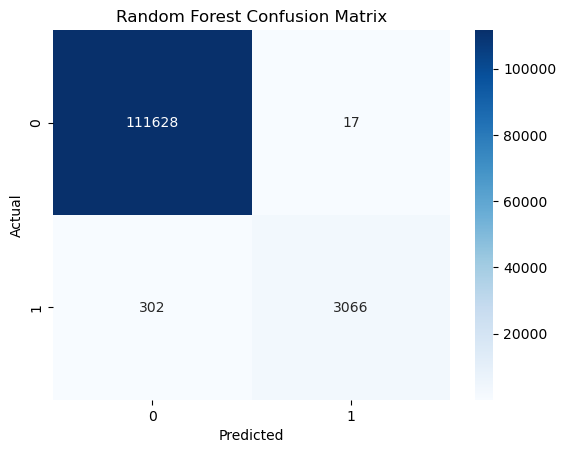

In [9]:
y_pred = rf.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

ROC-AUC: 0.9615238919509571


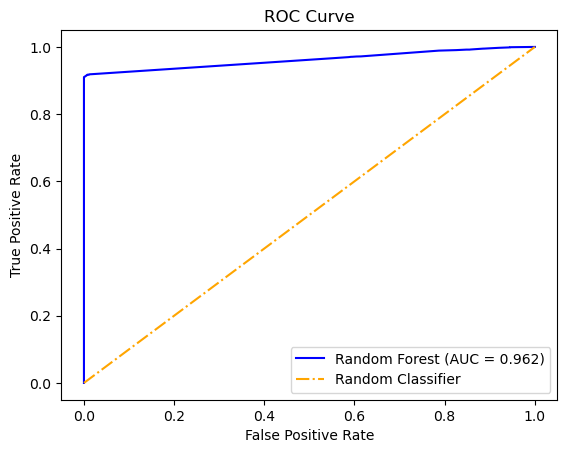

In [10]:
y_prob = rf.predict_proba(x_test)[:,1]

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)


fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], linestyle='dashdot', color='orange', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()